# NO₂ multivariate regression + with assumption checks
Regress hourly NO₂ on weather, time, and location features, check all standard regression assumptions, and report cluster-robust results. Goal: understand what drives NO₂ and how much, with honest uncertainty.

In [1]:
import pandas as pd, numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import scipy.stats as st

df = pd.read_parquet('master_hourly.parquet')
df = df[df['hours_since_obs'] == 0].copy()      # guardrail: real readings only
df['weekend'] = df['dow'] >= 5

cont = ['temp','rhum','wspd_ms','wind_u','prcp',
        'canopy_pct','impervious_pct','dist_downtown_m',
        'road_len_expwy_500','industrial_m2_500']

# aligned frame: drop NaN across EVERY column the formula uses, so rows line up for clustering
need = cont + ['no2','hour','weekend','is_holiday','month','sensor_id']
dm = df.dropna(subset=need).copy()
dm['sensor_code'] = pd.factorize(dm['sensor_id'])[0]   # integer codes for cluster SEs
print("rows:", len(dm))

rows: 1207135


## Data and setup
One aligned frame (dm): real readings only (hours_since_obs==0), and we drop rows missing any model variable so they line up for clustering. Leakage columns (no2_city, log_pm25_city) and wdir are excluded by design; wind_u is the model-safe wind variable.


In [2]:
f = ('no2 ~ temp+rhum+wspd_ms+wind_u+prcp'
     '+canopy_pct+impervious_pct+dist_downtown_m+road_len_expwy_500+industrial_m2_500'
     '+C(hour)+weekend+is_holiday+C(month)')
m = smf.ols(f, data=dm).fit()
resid, fitted = m.resid, m.fittedvalues
print('R2', round(m.rsquared, 3))
print(m.params.round(3))

R2 0.283
Intercept             22.125
C(hour)[T.1]          -0.213
C(hour)[T.2]          -0.127
C(hour)[T.3]          -0.227
C(hour)[T.4]           0.166
C(hour)[T.5]           0.881
C(hour)[T.6]           1.781
C(hour)[T.7]           2.672
C(hour)[T.8]           1.791
C(hour)[T.9]           1.095
C(hour)[T.10]          0.345
C(hour)[T.11]         -0.298
C(hour)[T.12]         -0.710
C(hour)[T.13]         -0.684
C(hour)[T.14]         -0.569
C(hour)[T.15]         -0.373
C(hour)[T.16]          0.284
C(hour)[T.17]          0.865
C(hour)[T.18]          1.204
C(hour)[T.19]          1.649
C(hour)[T.20]          1.382
C(hour)[T.21]          1.117
C(hour)[T.22]          0.723
C(hour)[T.23]          0.252
weekend[T.True]       -1.972
is_holiday[T.True]    -2.209
C(month)[T.2]         -0.067
C(month)[T.3]         -0.633
C(month)[T.4]         -4.620
C(month)[T.5]         -3.062
C(month)[T.6]         -4.404
C(month)[T.7]         -3.018
C(month)[T.8]         -3.504
C(month)[T.9]         -3.759
C(mon

The model explains R² = 0.28 of hourly NO₂ from weather + time + location (no lags). Raw coefficients aren't comparable across units yet (see standardized version below).

In [12]:
print("uncontrolled no2~temp slope:", smf.ols('no2 ~ temp', data=dm).fit().params['temp'].round(3))

uncontrolled no2~temp slope: -0.099


Temperature is mostly a seasonal effect. On its own, temperature's slope is −0.099. After we add month (season), it shrinks about 60% to −0.038 but stays real.
Understanding: in winter, cold air and trapped pollution, explains most of the raw temperature link.

## Collinearity (VIF)

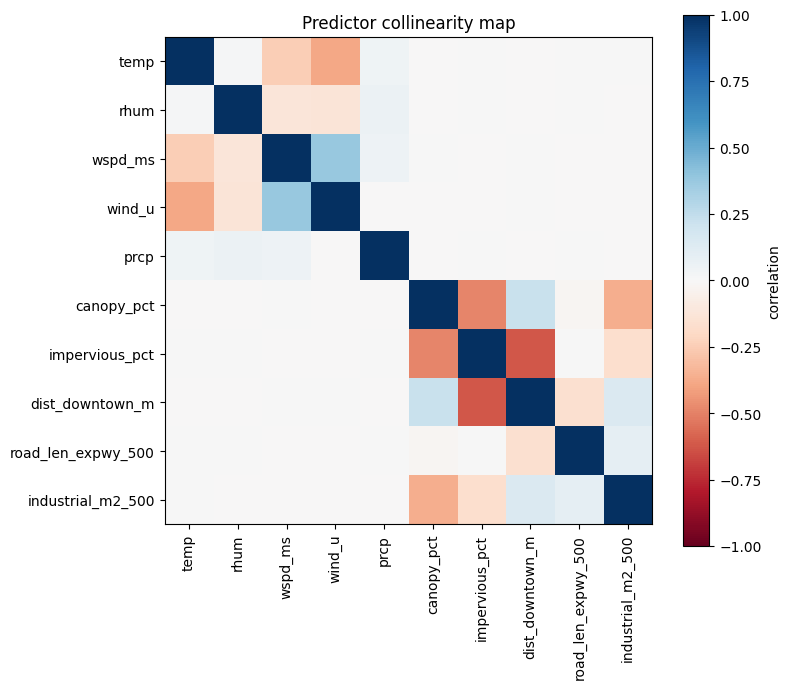

In [3]:
plt.figure(figsize=(8,7))
corr = dm[cont].corr()
plt.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
plt.xticks(range(len(cont)), cont, rotation=90); plt.yticks(range(len(cont)), cont)
plt.colorbar(label='correlation'); plt.title('Predictor collinearity map'); plt.tight_layout(); plt.show()

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
X = add_constant(dm[cont])
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns)
print(vif.round(2))

const                 1.00
temp                  1.20
rhum                  1.03
wspd_ms               1.20
wind_u                1.32
prcp                  1.01
canopy_pct            1.80
impervious_pct        2.35
dist_downtown_m       1.71
road_len_expwy_500    1.05
industrial_m2_500     1.41
dtype: float64


VIF all < 2.5 means multicollinearity is mild and no reduncdancy problem. Even though canopy and pavement are related, each predictor carries its own information, so we keep them all.

## Assumption checks

### 1. Independence of errors

In [5]:
from statsmodels.stats.stattools import durbin_watson
print("Durbin-Watson:", round(durbin_watson(resid), 3))   # <<2 = positive autocorrelation

# remedy: cluster-robust SEs by sensor (fixes autocorrelation + heteroscedasticity for inference)
m_robust = smf.ols(f, data=dm).fit(cov_type='cluster', cov_kwds={'groups': dm['sensor_code'].values})
cmp = pd.DataFrame({'coef': m.params, 'se_ols': m.bse, 'se_clustered': m_robust.bse})
cmp['t_clustered'] = (cmp['coef']/cmp['se_clustered']).round(1)
print(cmp.loc[['wspd_ms','temp','canopy_pct','impervious_pct','dist_downtown_m'],
              ['coef','se_ols','se_clustered','t_clustered']].round(4))

Durbin-Watson: 0.321
                   coef  se_ols  se_clustered  t_clustered
wspd_ms         -1.1204  0.0024        0.0163        -68.7
temp            -0.0380  0.0008        0.0059         -6.5
canopy_pct      -0.0377  0.0008        0.0206         -1.8
impervious_pct   0.0086  0.0005        0.0105          0.8
dist_downtown_m -0.0001  0.0000        0.0000         -2.0


The model’s errors are strongly related over time rather than independent: the Durbin–Watson value of about 0.32 is far below the ideal value of 2, so each hour's error is strongly tied to the one before. This means the usual OLS standard errors make the results look more precise than they really are, since the SE seem so small.

The fix is cluster-robust standard errors by sensor, which make the error bars 7–25× wider. With honest error bars, wind and temperature stay clearly real, but canopy and distance become only borderline. The naive model overstated how certain we were.

### 2 & 3. Linearity + homoscedasticity (residuals vs fitted)

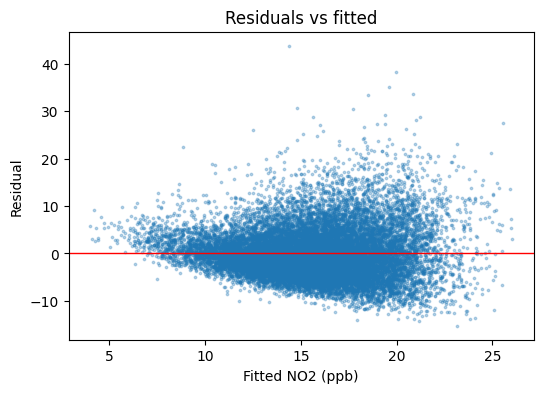

In [6]:
samp = np.random.default_rng(0).choice(len(resid), 20000, replace=False)
plt.figure(figsize=(6,4))
plt.scatter(fitted.iloc[samp], resid.iloc[samp], s=3, alpha=0.3)
plt.axhline(0, color='red', lw=1)
plt.xlabel('Fitted NO2 (ppb)'); plt.ylabel('Residual'); plt.title('Residuals vs fitted'); plt.show()

They sit around zero across the whole range — no systematic curve, so the straight-line fit is okay overall. But the spread widens for higher predicted NO₂ (unequal variance), and there's a longer upper tail (a few very high-pollution hours the model under-predicts). Both are mild and are handled by the cluster-robust errors.

In [7]:
from statsmodels.stats.diagnostic import het_breuschpagan
bp = het_breuschpagan(resid, m.model.exog)
print("Breusch-Pagan p-value:", f"{bp[1]:.3g}")   # ~0 expected at this n; judge from the plot, clustered SEs handle it

Breusch-Pagan p-value: 0


Equal-variance test. Breusch–Pagan flags unequal variance (p ≈ 0), but with over a million rows this test rejects almost automatically — so we judge from the plot above. The robust errors already account for it.

### 4. Normality of residuals

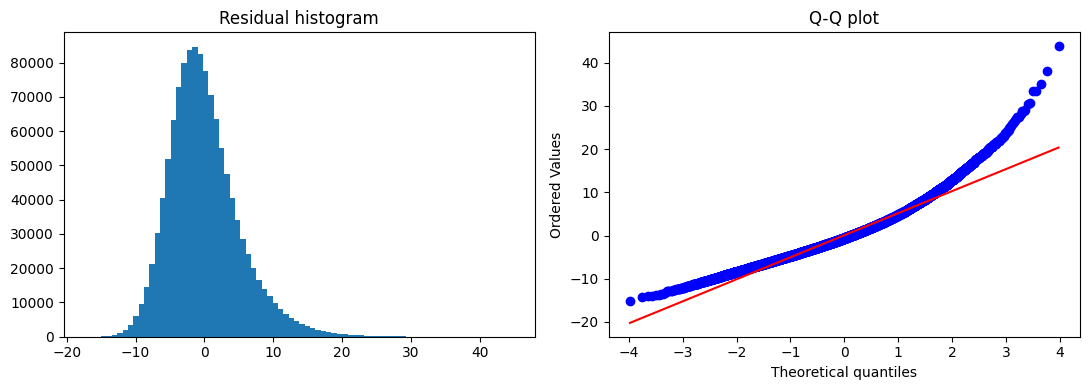

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(resid, bins=80); ax[0].set_title('Residual histogram')
st.probplot(resid.iloc[samp], dist='norm', plot=ax[1]); ax[1].set_title('Q-Q plot')
plt.tight_layout(); plt.show()

Residual normality is not required for OLS coefficient estimation. At this sample size, a formal normality test would reject even trivial departures from normality and would not be practically informative. The Q–Q plot is therefore used to assess whether residuals are broadly symmetric and approximately normal through the middle of the distribution; the tails should be inspected for notable departures. The Q-Q plot is roughly straight in the middle with heavier tails (the high-pollution hours)

sensors: 274
count    274.000
mean       0.803
std        0.033
min        0.697
25%        0.785
50%        0.803
75%        0.822
max        0.896
dtype: float64
share with autocorr > 0.3: 1.0


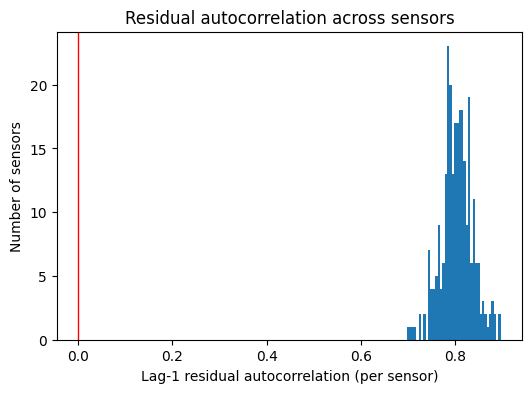

In [11]:
# Independence, per sensor: lag-1 residual autocorrelation within each sensor
tmp = dm[['sensor_id','ts_utc']].copy()
tmp['resid'] = m.resid.values                      # aligned to dm (model was fit on dm)

def lag1_acf(g):
    r = g.sort_values('ts_utc')['resid']
    return r.autocorr(lag=1) if len(r) >= 10 else np.nan

ac = tmp.groupby('sensor_id').apply(lag1_acf, include_groups=False).dropna()
print("sensors:", len(ac))
print(ac.describe().round(3))
print("share with autocorr > 0.3:", round((ac > 0.3).mean(), 3))

plt.figure(figsize=(6,4))
plt.hist(ac, bins=40)
plt.xlabel('Lag-1 residual autocorrelation (per sensor)')
plt.ylabel('Number of sensors')
plt.title('Residual autocorrelation across sensors')
plt.axvline(0, color='red', lw=1)
plt.show()

This hour's error correlated about 0.80 with the previous hour.
Note: Since missing hours were dropped, "lag-1" occasionally spans a gap rather than exactly one hour.

### 5. Influential outliers (Cook's distance, on a 50k sample)

In [9]:
s2 = dm.sample(50000, random_state=0)
cooks = smf.ols(f, data=s2).fit().get_influence().cooks_distance[0]
thr = 4/len(s2)
print(f"max Cook's D = {cooks.max():.4f}  | threshold 4/n = {thr:.6f}  | points over = {(cooks>thr).sum()}")

max Cook's D = 0.0033  | threshold 4/n = 0.000080  | points over = 2252


No single point drives the result. The largest Cook's distance is about 0.003 — far below any concern level (0.5–1). (Computed on a 50k sample — the full hat matrix is infeasible at 1.2M rows.)

## Standardized coefficients (comparable effect sizes)

In [10]:
dz = dm.copy()
for c in cont:
    dz[c] = (dz[c] - dz[c].mean()) / dz[c].std()
m2 = smf.ols(f, data=dz).fit()
print(m2.params[cont].round(3))

temp                 -0.446
rhum                  0.256
wspd_ms              -2.554
wind_u               -0.216
prcp                  0.083
canopy_pct           -0.285
impervious_pct        0.135
dist_downtown_m      -0.337
road_len_expwy_500    0.167
industrial_m2_500     0.135
dtype: float64


What matters most (per 1 standard deviation): wind (−2.55, highest), then temperature (−0.45), distance to downtown (−0.34), canopy (−0.29), humidity (+0.26).

## Conclusions
- Weather, location, time explain 28% of hourly NO2, remaining is explained by lags
- Wind is the most dominant driver
- From location: more NO₂ near downtown, expressways, industry; less with more tree canopy
- Assumptions: errors are strongly autocorrelated (not independent), so we use cluster-robust standard errors; variance is mildly unequal; normality isn't needed at this size; no influential outliers; collinearity is low.